<h1 align="center">SWDB Problem Set: Becoming a Data Detective</h1>
<h3 align="center">From someone else's figure to your own analysis</h3>
<p align="center"><b>SOLUTIONS</b> &mdash; worked on the Dynamic Routing dataset (Neuropixels)</p>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>How this problem set works</h2>

This morning you explored a dataset and made figures. Those figures are now posted on Slack.

**Your starting point is one of your classmates' figures.** Pick any figure from the channel, along
with the dataset it came from &mdash; ideally one you did *not* work on this morning.

| Part | Task |
| --- | --- |
| 1 | Load their dataset and find the pieces the figure needs |
| 2 | Reproduce the figure, and interrogate what it shows |
| 3 | Align activity to event onsets: raster and PSTH |
| 4 | Signal and noise correlations, and whether to trust them |

You already have the data-access skills for Part 1 from this morning's tutorial. This problem set is
about what comes after loading: **shaping data, and checking whether the result means anything.**

**Deliverable:** a short README naming the figure and dataset you chose, the decisions you made at
each step, and an honest assessment of what your numbers do and do not support.

<b>Every dataset is different, and the notebook does not know which one you picked.</b> The code
cells are prompts, not templates &mdash; you write what goes in them, using the access patterns from
this morning. Only a few things are given: the imports, and two helper functions from the tutorial.

The differences you will run into are not cosmetic. Across the datasets in this workshop:

- **Recording modality** &mdash; a continuous calcium signal in some, discrete spike times in
  others. Spikes need binning before anything here applies.
- **Sampling rate** &mdash; from a few Hz to tens of kHz, which sets what timing you can resolve.
- **Number of neurons** &mdash; tens to thousands, which changes what is tractable in one pass.
- **Stimulus structure** &mdash; many conditions with few repeats, few conditions with many, or no
  sensory stimulus at all.
- **What was recorded alongside** &mdash; running, licking, pupil, reward; some datasets have all of
  it, some none.
- **Where things live in the file** &mdash; container and column names differ, and so does which
  container holds the trial table.

None of that is written on the outside of the file. **You have to look.** Part of each prompt is
deciding whether the analysis it asks for even applies to your dataset &mdash; and saying so when it
does not.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Taking it slow: Analysis step by step</h2>

You can now generate an analysis faster than you can check one. Ask an LLM for a correlation matrix
and you will have one in thirty seconds, beautifully formatted, with a colorbar.

The problem is that a result computed on four trials can look exactly like a result computed on four
hundred. A bug can look exactly like a finding. A correlation computed in a window where nothing
happened can look exactly like a real effect.

So the questions to keep asking are:

- **What is actually in this file?** Not what you assume &mdash; what is there.
- **Does this dataset support the question I am asking?**
- **How is the data being transformed?** Plot the data after each step.
- **What would make this result wrong?** Name it before you see the answer.

</div>

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 1: Load the dataset and find the pieces you need</h1>

Same access pattern as this morning: find your dataset's mount under <code>/data</code>, locate a
session's NWB file, then dot and bracket notation into the containers.

**Your classmate's figure tells you what to look for.** Before you open anything, list the pieces the
figure needs &mdash; neural activity, plus whatever else it plots: a behavioral trace, epoch
boundaries, trial times, stimulus identity.

Then find each one, and note the ones that turn out not to exist. **A piece being absent is a
finding about the dataset, not a failure.** Some datasets have no running wheel, no pupil camera, no
visual stimulus at all. You will build the figure from what is there.

</div>

In [70]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

data_dir = '/data'

In [71]:
for mount in sorted(os.listdir(data_dir)):
    print(mount)

427836_V1DD_Filtered
brain-computer-interface-v2
dynamicrouting_datacube
metadata
multiplane-ophys-behavior-nwb-combined-asset-swdb


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Start from the metadata table, not the file tree.</b> Each dataset has a metadata CSV in
<code>/code/metadata/</code> &mdash; one row per session, with subject, session type, date and the
asset name. Read that first and choose a session from it, because the filename alone will not tell you
which imaging stage or task condition you are looking at.

Then build the path: the NWB lives inside that dataset's mount under <code>/data/</code>.

</div>

In [72]:
metadata = pd.read_csv(os.path.join(data_dir, 'metadata', 'dynamic_routing_metadata.csv'))
print(metadata.shape)
print(metadata.columns.tolist())
metadata.head()

(1, 6)
['subject_id', 'session_id', 'session_type', 'session_date', 'name', 'golden_mouse']


   subject_id                 session_id    session_type session_date                                                     name  golden_mouse
0      708016  ecephys_686176_2023-12-04  DynamicRouting   2023-12-04  ecephys_686176_2023-12-04_processed_2026-08-19_00-00-00         False

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Which session does your classmate's figure come from? Use the table to find it
&mdash; subject, session type, date &mdash; and say what you filtered on.

Look at what the table offers before you filter. How many subjects, how many session types, how many
sessions each? That inventory is the first thing you know about the dataset.

</div>

In [73]:
candidates = metadata[metadata.subject_id == 708016]
print(f'{len(candidates)} sessions for this mouse')
session = candidates.iloc[0]
show = [c for c in ['subject_id', 'session_id', 'session_date', 'name']
        if c in candidates.columns]
print(session[show].to_string())

1 sessions for this mouse
subject_id                                                 708016
session_id                              ecephys_686176_2023-12-04
session_date                                           2023-12-04
name            ecephys_686176_2023-12-04_processed_2026-08-19...


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Now build the path.</b> An NWB file is either a single <code>.nwb</code> file (HDF5) or a
<code>.nwb.zarr</code> <i>directory</i>, and datasets here are packaged by different groups &mdash; the
file may sit at the top of the mount or a few levels down. Search for it rather than hardcoding a
path, and check you got exactly one match.

</div>

In [75]:
dataset_dir = os.path.join(data_dir, 'dynamicrouting_datacube')
session_dir = os.path.join(dataset_dir, session['name'])

# One session directory holds one NWB store. Match on 'nwb' in the name so this
# finds both forms: a .nwb file and a .nwb.zarr directory.
nwb_file = [path for path in os.listdir(session_dir) if 'nwb' in path]
print(len(nwb_file), 'nwb file(s) detected:', nwb_file)

assert len(nwb_file) == 1, f'expected one NWB store, found {len(nwb_file)}'
nwb_path = os.path.join(session_dir, nwb_file[0])
print(nwb_path)


1 NWB file(s) for this session
  dynamicrouting_datacube/ecephys_686176_2023-12-04_processed_2026-08-19_00-00-00/dynrout.nwb


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Did you get exactly one match? More than one usually means several processing
generations of the same session are attached &mdash; check which you picked. Zero means the session
in the table is not mounted in this capsule, which is worth knowing before you debug anything else.

</div>

In [76]:
# Which physical form is it? This decides the backend, and it is visible on disk:
#   a single .nwb FILE      -> HDF5, read by pynwb.NWBHDF5IO
#   a .nwb.zarr DIRECTORY   -> Zarr store, read by hdmf_zarr.NWBZarrIO
# pynwb.read_nwb inspects the path and picks the right one, so the same call
# works for both. It needs hdmf_zarr installed for the Zarr case, but you never
# import it yourself.
print('zarr store (directory)' if os.path.isdir(nwb_path) else 'HDF5 file')

nwb = pynwb.read_nwb(nwb_path)
print(type(nwb).__name__)


NWBFile


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Find the data the figure needs</h3>

Four containers hold almost everything. Which one holds what **varies by dataset**, so list all four
before you index into any of them.

| container | commonly holds |
| --- | --- |
| `processing` | processed neural activity, and often behavior |
| `intervals` | epoch tables, trial tables, stimulus presentation tables |
| `stimulus` | stimulus templates &mdash; but in some datasets, the trial tables too |
| `acquisition` | raw acquired signals |

The last row is not hypothetical: some datasets put their trial tables in `stimulus` and leave
`intervals` holding only epochs. If you look in one container, find nothing, and conclude the data
is missing, you will be wrong. **Print all four.**

</div>

In [77]:
print('processing :', list(nwb.processing.keys()))
print('intervals  :', list(nwb.intervals.keys()) if nwb.intervals else [])
print('acquisition:', list(nwb.acquisition.keys()))
print('stimulus   :', list(nwb.stimulus.keys()) if nwb.stimulus else [])
if getattr(nwb, 'units', None) is not None:
    print('units      : yes,', len(nwb.units), 'rows')

processing : ['behavior', 'ecephys']
intervals  : ['aud_rf_mapping_trials', 'epochs', 'performance', 'trials', 'vis_rf_mapping_trials']
acquisition: ['frametimes_eye_camera', 'frametimes_front_camera', 'frametimes_side_camera', 'manipulator_positions']
stimulus   : []
units      : yes, 4619 rows


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your dataset continuous or spiking?</b> This is the first fork in the road, and it
changes what "activity" even means.

<b>Continuous</b> (calcium imaging, LFP): a `(n_timepoints, n_cells)` array already exists in the
file. Find it and you are done.

<b>Spiking</b> (Neuropixels, sorted electrophysiology): there is no such array. Each unit carries its
own list of spike times, usually in a `units` table, and you must <b>bin</b> them yourself &mdash;
choose a bin width, count spikes per bin, divide by the width to get a rate in spikes/s. Everything
downstream then works the same way.

Two decisions come with spiking data, and neither has a default:

- <b>Which units.</b> Spike sorting produces more units than you should analyze. There will be
  quality-control columns (`is_qc_pass`, `firing_rate`, `presence_ratio`, `snr`) and often an
  anatomical label. Select on them explicitly and say what you selected &mdash; a session can drop
  from thousands of units to dozens, and the ones you drop change your answer.
- <b>Bin width.</b> Too wide blurs the response; too narrow leaves mostly-empty bins and noisy
  single-trial estimates. Try a few and see how much your answer moves.

<pre>
bin_width = 0.010                                    # seconds -- your decision
edges = np.arange(0, t_end + bin_width, bin_width)
counts, _ = np.histogram(one_unit_spike_times, bins=edges)
rate = counts / bin_width                            # spikes/s
bin_centres = edges[:-1] + bin_width / 2
</pre>

Sparse binned spikes behave like a deconvolved calcium trace: sharper in time, and noisy per
trial.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Two things to check as you pull out the activity trace.</b>

<b>Timestamps.</b> Some datasets store an explicit `timestamps` array; others store a sampling
`rate` and a `starting_time`, and you reconstruct the times yourself. Everything downstream needs
real times in seconds, so check which you have &mdash; `series.timestamps` is `None` when the file
uses a rate.

<b>Lazy loading.</b> NWB data objects do not load until you index them. That is what lets you open a
50&nbsp;GB file instantly, but it means `data.std()` may fail where `np.std(data)` works. Convert
with `np.asarray()` once you know the array is small enough to hold, or slice first.

</div>

In [78]:
# This is a SPIKING dataset. There is no continuous activity array anywhere --
# each unit has its own list of spike times, so we have to build the matrix by binning.
units = nwb.units.to_dataframe()
print('units table:', units.shape)
print('quality columns:', [c for c in units.columns if 'qc' in c or c in ('firing_rate', 'snr', 'presence_ratio')])

# Select units before doing anything else: quality control, then a brain area.
position = {uid: i for i, uid in enumerate(units.index)}
selected = units[units.is_qc_pass.astype(bool)
                 & (units.firing_rate > 1.0)
                 & units.structure.isin(['VISp', 'VISl'])]
print(f'{len(units)} units -> {len(selected)} after QC, rate and area selection')
print(selected.structure.value_counts().to_dict())

# Bin the spikes into a (n_bins, n_units) rate matrix.
bin_width_s = 0.010     # seconds -- a real decision, see the note below
spike_lists = [nwb.units['spike_times'][position[uid]] for uid in selected.index]
t_end = max(s.max() for s in spike_lists) + 1
edges = np.arange(0, t_end + bin_width_s, bin_width_s)

spike_rates = np.zeros((len(edges) - 1, len(selected)), dtype=np.float32)
for j, s in enumerate(spike_lists):
    counts, _ = np.histogram(s, bins=edges)
    spike_rates[:, j] = counts / bin_width_s       # spikes/s
# Timestamp each bin at its CENTRE. A bin covers [edge, edge + bin_width), so
# its centre is the time its value best represents -- label it by the leading
# edge and a plot puts post-onset spikes right on the event marker.
ts = edges[:-1] + bin_width_s / 2

print('\nbinned rate matrix:', spike_rates.shape, '(bins, units)')
print(f'bin width {bin_width_s*1000:.0f} ms | mean rate {spike_rates.mean():.2f} Hz')
print(f'fraction of bins with no spike: {(spike_rates == 0).mean():.3f}')
print(f'session duration: {ts[-1]/60:.1f} min')
plane = 'VISp+VISl'

units table: (4619, 59)
quality columns: ['default_qc', 'firing_rate', 'is_qc_pass', 'presence_ratio', 'snr']
4619 units -> 84 after QC, rate and area selection
{'VISp': 63, 'VISl': 21}

binned rate matrix: (138902, 84) (bins, units)
bin width 50 ms | mean rate 3.76 Hz
fraction of bins with no spike: 0.842
session duration: 115.8 min


In [79]:
# Two separate trial tables here: the task, and receptive-field mapping.
task_trials = nwb.intervals['trials'].to_dataframe()
rf_trials = nwb.intervals['vis_rf_mapping_trials'].to_dataframe()

running = nwb.processing['behavior']['running_speed']
running_speed = running.data[:]
running_ts = running.timestamps[:]

licks = nwb.processing['behavior']['licks']

print('task trials:      ', task_trials.shape)
print('rf mapping trials:', rf_trials.shape)
print('running_speed:    ', running_speed.shape)
print('\nrf mapping columns:', list(rf_trials.columns))

task trials:       (523, 49)
rf mapping trials: (1224, 11)
running_speed:     (376756,)

rf mapping columns: ['start_time', 'stop_time', 'stim_start_time', 'stim_stop_time', 'trial_index', 'is_small_field_grating', 'grating_orientation', 'grating_x', 'grating_y', 'is_full_field_flash', 'flash_contrast']


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Quality control: which cells or units belong in the analysis?</h3>

Segmentation and spike sorting are automated, and both over-produce. An ophys plane contains ROIs the
classifier thinks are not cell bodies; a sorted probe contains units that drift, that are barely
above noise, or that are two neurons merged. <b>The activity matrix you just loaded usually contains
all of them.</b>

Pipelines record their own verdicts. For imaging they live on the ROI table beside the masks; for
electrophysiology, on the units table. The columns differ by pipeline and by dataset &mdash; boolean
flags, continuous probabilities, morphology metrics, contamination estimates &mdash; so there is no
list to memorise. Print the columns and see what your dataset offers.

Filtering is not automatically the right move, and the criteria are yours to justify. But
<b>inheriting the unfiltered set by default is a decision you made without noticing</b>, and it is the
kind that never appears in a methods section.

</div>

In [80]:
# Electrophysiology: the QC columns live on the units table, not a segmentation.
units = nwb.units.to_dataframe()
print('units table:', units.shape)
qc_cols = [c for c in units.columns
           if any(k in c.lower() for k in
                  ('qc', 'snr', 'presence', 'firing_rate', 'isi', 'amplitude', 'contam'))]
print('candidate QC columns:', qc_cols)
for c in qc_cols:
    v = units[c]
    if v.dtype == object:
        continue
    if set(np.unique(v)) <= {0, 1, True, False}:
        print(f'  {c:28s} flag     {int(v.sum())} True / {len(v)}')
    else:
        print(f'  {c:28s} {str(v.dtype):8s} min {v.min():.3g}  max {v.max():.3g}')
roi_table = units

units table: (4619, 59)
candidate QC columns: ['amplitude', 'amplitude_cutoff', 'amplitude_cv_median', 'amplitude_cv_range', 'amplitude_median', 'default_qc', 'firing_rate', 'is_qc_pass', 'isi_violations_count', 'isi_violations_ratio', 'presence_ratio', 'rp_contamination', 'snr', 'spike_amplitudes']
  amplitude                    float64  min 8.87  max 1.47e+03
  amplitude_cutoff             float64  min 1.68e-06  max 0.5
  amplitude_cv_median          float64  min 0.0677  max 22.3
  amplitude_cv_range           float64  min 0.0373  max 52.8
  amplitude_median             float64  min 2.34  max 1.11e+03
  default_qc                   flag     1468 True / 4619
  firing_rate                  float64  min 0.000433  max 47.7
  is_qc_pass                   flag     1468 True / 4619
  isi_violations_count         float64  min 0  max 2.23e+03
  isi_violations_ratio         float64  min 0  max 4.36e+03
  presence_ratio               float64  min 0.0261  max 1
  rp_contamination             flo

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Does your dataset carry per-cell or per-unit quality metrics? Report what the
columns are, how many entries each flag would exclude, and whether the activity matrix is already
filtered or contains everything.

Then decide. Whatever you choose, **state the criterion and the count you dropped** &mdash; that
sentence belongs in your methods.

</div>

In [81]:
# Already applied when the units were selected and binned above: is_qc_pass,
# firing_rate > 1 Hz, and area in VISp/VISl. State it rather than re-filtering.
print(f'{len(units)} sorted units -> {spike_rates.shape[1]} kept '
      f'(is_qc_pass & firing_rate > 1 Hz & area in VISp/VISl)')
spike_rates = np.asarray(spike_rates)
events_raw = None
print('activity matrix after QC:', spike_rates.shape)

4619 sorted units -> 84 kept (is_qc_pass & firing_rate > 1 Hz & area in VISp/VISl)
activity matrix after QC: (138902, 84)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Plotting a long recording.</b> A whole session at a fine sampling rate can be hundreds of
thousands of points &mdash; slow to draw and impossible to read. Plot a slice instead, but choose the
slice from the data rather than picking a round number: an arbitrary window can easily contain no
activity at all, and an empty panel looks identical to a broken one.

</div>

plotting unit 61 (SNR 6.31, median 3.95)
showing 120 s from 4221 s (233 non-empty bins)


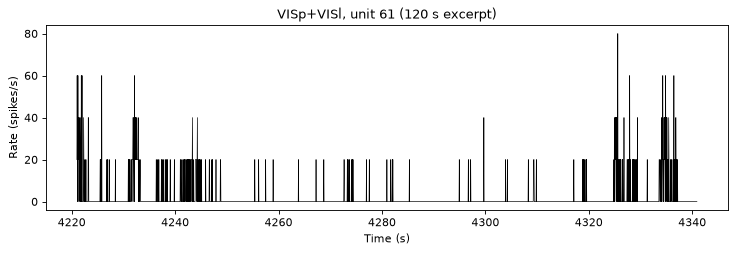

In [82]:
spike_rates = np.asarray(spike_rates)
usable_cells = np.flatnonzero(~np.isnan(spike_rates).all(axis=0))
snr = np.percentile(spike_rates[:, usable_cells], 99, axis=0) / np.std(spike_rates[:, usable_cells], axis=0)
example_roi = int(usable_cells[np.argmax(snr)])
print(f'plotting unit {example_roi} (SNR {snr.max():.2f}, median {np.median(snr):.2f})')

# At 10 ms bins a whole session is 700k points -- plot a slice, not everything.
# Choose the slice where this unit is actually active, not an arbitrary time.
active = ts[spike_rates[:, example_roi] > 0]
t_start = float(active[len(active) // 2])
window = (ts > t_start) & (ts < t_start + 120)
print(f'showing 120 s from {t_start:.0f} s '
      f'({int((spike_rates[window, example_roi] > 0).sum())} non-empty bins)')
plt.figure(figsize=(11, 3))
plt.plot(ts[window], spike_rates[window, example_roi], 'k', lw=0.6)
plt.xlabel('Time (s)')
plt.ylabel('Rate (spikes/s)')
plt.title(f'{plane}, unit {example_roi} (120 s excerpt)')
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Look at that trace for a few seconds before moving on. Is anything about it
surprising? Would you have noticed if you had skipped straight to the analysis?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Set up the main variables for this dataset</h3>

Point these names at the equivalent pieces of your own NWB file. Later sections reference them,
so getting them right here saves repeating yourself &mdash; but edit anything you like as you go.
This is your notebook now.

</div>

In [83]:
task_trials

     start_time   stop_time  quiescent_start_time  quiescent_stop_time  stim_start_time  stim_stop_time  response_window_start_time  response_window_stop_time  task_control_response_time  response_time  reward_time  post_response_window_start_time  post_response_window_stop_time stim_name  grating_phase  block_index rewarded_modality  trial_index  trial_index_in_block  repeat_index  is_response  is_correct  is_incorrect  is_hit  is_false_alarm  is_correct_reject  is_miss  is_go  is_nogo  is_rewarded  is_noncontingent_reward  is_contingent_reward  is_reward_scheduled  is_instruction  is_aud_stim  is_vis_stim  is_catch  is_target  is_aud_target  is_vis_target  is_nontarget  is_aud_nontarget  is_vis_nontarget  is_vis_rewarded  is_aud_rewarded  is_block_switch  is_repeat  is_opto  is_task_control_correct
id                                                                                                                                                                                          

In [85]:
activity = spike_rates                       # (n_bins, n_units) binned spike rates
timestamps = ts                      # (n_bins,) bin centres in seconds
events = task_trials                   # one row per stimulus presentation

activity_events = None

print('activity:', np.shape(activity), '| events:', events.shape)

activity: (138902, 84) | events: (523, 49)


In [84]:
events

     start_time   stop_time  quiescent_start_time  quiescent_stop_time  stim_start_time  stim_stop_time  response_window_start_time  response_window_stop_time  task_control_response_time  response_time  reward_time  post_response_window_start_time  post_response_window_stop_time stim_name  grating_phase  block_index rewarded_modality  trial_index  trial_index_in_block  repeat_index  is_response  is_correct  is_incorrect  is_hit  is_false_alarm  is_correct_reject  is_miss  is_go  is_nogo  is_rewarded  is_noncontingent_reward  is_contingent_reward  is_reward_scheduled  is_instruction  is_aud_stim  is_vis_stim  is_catch  is_target  is_aud_target  is_vis_target  is_nontarget  is_aud_nontarget  is_vis_nontarget  is_vis_rewarded  is_aud_rewarded  is_block_switch  is_repeat  is_opto  is_task_control_correct
id                                                                                                                                                                                          

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Print the columns of your stimulus table. Which describe *what was
presented*, which describe *what the animal did*, and which are bookkeeping?

Note any column whose meaning you cannot guess &mdash; that is a databook lookup for your README.

</div>

In [86]:
print(list(events.columns))
events.head()

['start_time', 'stop_time', 'quiescent_start_time', 'quiescent_stop_time', 'stim_start_time', 'stim_stop_time', 'response_window_start_time', 'response_window_stop_time', 'task_control_response_time', 'response_time', 'reward_time', 'post_response_window_start_time', 'post_response_window_stop_time', 'stim_name', 'grating_phase', 'block_index', 'rewarded_modality', 'trial_index', 'trial_index_in_block', 'repeat_index', 'is_response', 'is_correct', 'is_incorrect', 'is_hit', 'is_false_alarm', 'is_correct_reject', 'is_miss', 'is_go', 'is_nogo', 'is_rewarded', 'is_noncontingent_reward', 'is_contingent_reward', 'is_reward_scheduled', 'is_instruction', 'is_aud_stim', 'is_vis_stim', 'is_catch', 'is_target', 'is_aud_target', 'is_vis_target', 'is_nontarget', 'is_aud_nontarget', 'is_vis_nontarget', 'is_vis_rewarded', 'is_aud_rewarded', 'is_block_switch', 'is_repeat', 'is_opto', 'is_task_control_correct']


    start_time   stop_time  quiescent_start_time  quiescent_stop_time  stim_start_time  stim_stop_time  response_window_start_time  response_window_stop_time  task_control_response_time  response_time  reward_time  post_response_window_start_time  post_response_window_stop_time stim_name  grating_phase  block_index rewarded_modality  trial_index  trial_index_in_block  repeat_index  is_response  is_correct  is_incorrect  is_hit  is_false_alarm  is_correct_reject  is_miss  is_go  is_nogo  is_rewarded  is_noncontingent_reward  is_contingent_reward  is_reward_scheduled  is_instruction  is_aud_stim  is_vis_stim  is_catch  is_target  is_aud_target  is_vis_target  is_nontarget  is_aud_nontarget  is_vis_nontarget  is_vis_rewarded  is_aud_rewarded  is_block_switch  is_repeat  is_opto  is_task_control_correct
id                                                                                                                                                                                           

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 2: Reproduce the figure, and interrogate what it shows</h1>

You have your classmate's figure. You do not have their code, and you may not have a caption either.

<b>Before you write anything, write down what you think the figure shows.</b> One or two sentences,
in your notebook, as a claim someone could disagree with: <i>"activity is higher during X than during
Y"</i>, <i>"the response is larger on this trial type"</i>, <i>"these two signals rise together."</i>

Two reasons this comes first. It commits you to an interpretation before the data can talk you into
one &mdash; and it converts a picture into something you can actually test. A figure cannot be right
or wrong. A claim can.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write your claim about the figure you picked, in the cell below, before you
write any code.

Be specific enough to be wrong. "There is neural activity" is not a claim; "population activity is
higher in the second half of the session" is.

</div>

_Your claim:_

<!-- write it here -->


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Now rebuild it</h3>

Get the pieces the figure needs and plot them. You will not match it exactly &mdash; different
smoothing, different colors, a different subset of cells &mdash; and that is fine. What matters is
that the structure you see is the same structure they saw.

If you cannot rebuild some element because the dataset does not contain it, note that and rebuild
what you can.

</div>

In [89]:
population_rate = activity.mean(axis=1)

print('activity:  ', activity.shape, '(timepoints, cells)')
print('population:', population_rate.shape, '(timepoints,)')

activity:   (138902, 84) (timepoints, cells)
population: (138902,) (timepoints,)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To shade the epochs we need their start and stop times. Where epochs live varies by dataset:
sometimes an `epoch_name` column on the stimulus table, sometimes a separate epochs table.

**Check that the column you group by actually varies.** If it takes one value, you will get a single
block spanning the session &mdash; a figure that looks fine and is wrong.

</div>

In [90]:
for column in ['epoch_name', 'stim_name', 'stimulus_block_name', 'stimulus_name']:
    if column in events.columns:
        print(f'{column}: {events[column].nunique()} distinct value(s)')
        print(events[column].value_counts().to_string())
        print()
print('nothing epoch-like in the event table; check nwb.intervals instead')

stim_name: 5 distinct value(s)
stim_name
sound1    124
vis1      123
sound2    109
vis2      107
catch      60

nothing epoch-like in the event table; check nwb.intervals instead


In [91]:
epochs = nwb.intervals['epochs'].to_dataframe()
epochs['label'] = [t[0] if isinstance(t, (list, np.ndarray)) and len(t) else f'epoch_{i}'
                   for i, t in enumerate(epochs.get('tags', [[]] * len(epochs)))]
epochs = epochs.set_index('label')[['start_time', 'stop_time']].sort_values('start_time')
epochs['duration_s'] = (epochs.stop_time - epochs.start_time).round(1)
epochs

              start_time    stop_time  duration_s
label                                            
mapping        52.508480   923.255600       870.7
spontaneous  1411.213730  2014.302280       603.1
rewards      2037.872100  2641.010885       603.1
task         2652.603865  6301.913620      3649.3
rewards      6313.390060  6916.512310       603.1

In [92]:
# Shade each epoch a different color -- same helper as the tutorial
colors = dict(zip(epochs.index, plt.cm.Pastel1.colors))


def shade_epoch_blocks(ax):
    """Shade each epoch on `ax`, one colour per epoch label.

    Epochs are the coarse structure of the session -- which stimulus block or
    task phase was running. Shading them behind a trace shows at a glance
    whether a change in activity lines up with a change in what was happening.
    """
    for label, row in epochs.iterrows():
        # zorder=0 keeps the shading BEHIND the data; alpha so the trace on top
        # stays readable. label= puts each epoch in the legend once.
        ax.axvspan(row.start_time, row.stop_time, color=colors[label],
                   alpha=0.5, zorder=0, label=label)


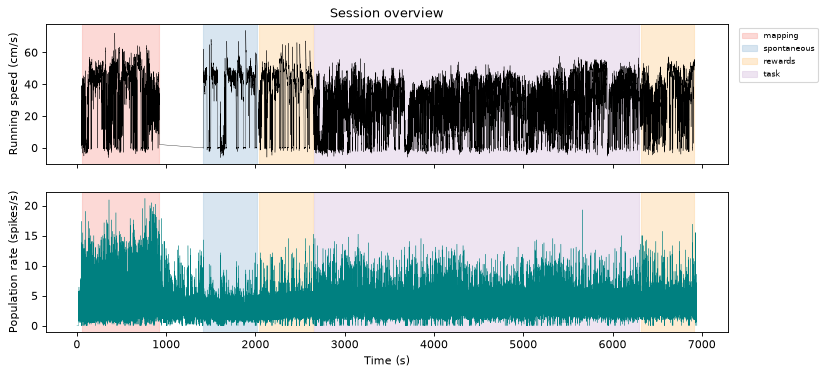

In [93]:
panels = [(timestamps, population_rate, "Population rate (spikes/s)", 'teal')]
if 'running_speed' in dir():
    panels.insert(0, (running_ts, running_speed, "Running speed (cm/s)", 'k'))

fig, axes = plt.subplots(len(panels), 1, figsize=(11, 2.5*len(panels)), sharex=True, squeeze=False)
axes = axes[:, 0]
for ax, (x, y, ylabel, color) in zip(axes, panels):
    ax.plot(x, y, color=color, lw=0.3)
    ax.set_ylabel(ylabel)
    shade_epoch_blocks(ax)
axes[0].set_title('Session overview')
axes[-1].set_xlabel('Time (s)')
h, l = axes[0].get_legend_handles_labels()
uniq = dict(zip(l, h))
axes[0].legend(uniq.values(), uniq.keys(), bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=7)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now test the claim you wrote above &mdash; do not eyeball it.

Turn your sentence into a number you can check. If it compares epochs, compute the mean in each one,
alongside how long each epoch lasted, when in the session it happened, and what the animal was doing.
If it compares something else, compute the equivalent.

Before you look: **what would make this comparison unfair?** Write your answer down first, then see
whether the table bears it out.

Then go back and mark your claim as supported, contradicted, or untestable with this data. All three
are legitimate outcomes and all three belong in your README.

</div>

In [94]:
response_rows = []
for label, row in epochs.iterrows():
    in_epoch = (timestamps >= row.start_time) & (timestamps < row.stop_time)
    in_run = (running_ts >= row.start_time) & (running_ts < row.stop_time)
    if in_epoch.sum() < 10:
        continue
    response_rows.append({'epoch': label,
                 'duration_s': round(float(row.stop_time - row.start_time), 1),
                 'n_samples': int(in_epoch.sum()),
                 'mid_session_min': round(float(row.start_time + row.stop_time) / 120, 1),
                 'mean_running': round(float(running_speed[in_run].mean()), 2) if in_run.sum() else np.nan,
                 'mean_activity': round(float(population_rate[in_epoch].mean()), 4)})

pd.DataFrame(response_rows)

         epoch  duration_s  n_samples  mid_session_min  mean_running  mean_activity
0      mapping       870.7      17415              8.1         34.05         4.4101
1  spontaneous       603.1      12062             28.5         32.15         2.7624
2      rewards       603.1      12063             39.0         34.99         3.3251
3         task      3649.3      72986             74.6         28.25         3.8760
4      rewards       603.1      12063            110.2         31.20         3.9702

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 3: Align activity to event onsets</h1>

The session overview shows everything at once, which means it shows very little. To see a response
you need to **align** activity to the times when something happened, and look across repeats.

"Something happened" need not be a visual stimulus. It might be a sound, an optogenetic pulse, a
reward, a lick, or the start of a trial. Anything with a repeatable onset time works the same way
&mdash; and the rest of this notebook says "event" rather than "stimulus" for that reason.

This morning's tutorial averaged across presentations. Here we look at what the average hides.

</div>

In [95]:
# Which column labels the chosen_condition? Look at the candidates first.
for col in ['stim_name', 'is_vis_stim', 'is_aud_stim', 'is_target', 'rewarded_modality']:
    if col in events.columns:
        print(f'--- {col} ---')
        print(events[col].value_counts().head(10).to_string())
        print()
condition_column = 'stim_name'
events[condition_column].value_counts()

--- stim_name ---
stim_name
sound1    124
vis1      123
sound2    109
vis2      107
catch      60

--- is_vis_stim ---
is_vis_stim
False    293
True     230

--- is_aud_stim ---
is_aud_stim
False    290
True     233

--- is_target ---
is_target
False    276
True     247

--- rewarded_modality ---
rewarded_modality
vis    262
aud    261



stim_name
sound1    124
vis1      123
sound2    109
vis2      107
catch      60

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Are all of these events the same kind of event?</h3>

An event table usually contains rows that are **not equivalent trials**. Depending on the dataset
that might be first versus repeated presentations, rewarded versus unrewarded trials, different
stimulus families, trials the animal responded to versus ignored, blocks recorded before and after
a manipulation, or blank and omitted entries that are not events at all.

This matters before you align anything, for two reasons:

- **Response magnitude can differ several-fold between trial types.** Averaging them together dilutes
  the response toward whichever type is most numerous &mdash; which is often the weakest one.
- **Trial types differ in what else is happening.** Reward, licking, and arousal ride along with some
  trial types and not others, so a difference you attribute to the stimulus may not be about the
  stimulus.

Find the columns in your table that distinguish trial types, and count them.

</div>

In [96]:
events

     start_time   stop_time  quiescent_start_time  quiescent_stop_time  stim_start_time  stim_stop_time  response_window_start_time  response_window_stop_time  task_control_response_time  response_time  reward_time  post_response_window_start_time  post_response_window_stop_time stim_name  grating_phase  block_index rewarded_modality  trial_index  trial_index_in_block  repeat_index  is_response  is_correct  is_incorrect  is_hit  is_false_alarm  is_correct_reject  is_miss  is_go  is_nogo  is_rewarded  is_noncontingent_reward  is_contingent_reward  is_reward_scheduled  is_instruction  is_aud_stim  is_vis_stim  is_catch  is_target  is_aud_target  is_vis_target  is_nontarget  is_aud_nontarget  is_vis_nontarget  is_vis_rewarded  is_aud_rewarded  is_block_switch  is_repeat  is_opto  is_task_control_correct
id                                                                                                                                                                                          

In [97]:
for column in ['is_vis_stim', 'is_aud_stim', 'is_target', 'is_go', 'is_hit', 'is_miss']:
    if column in events.columns:
        print(f'{column}:')
        print(events[column].value_counts().to_string())
        print()

is_vis_stim:
is_vis_stim
False    293
True     230

is_aud_stim:
is_aud_stim
False    290
True     233

is_target:
is_target
False    276
True     247

is_go:
is_go
False    382
True     141

is_hit:
is_hit
False    385
True     138

is_miss:
is_miss
False    520
True       3



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To compare them we need to cut a window of data around each onset. Same
`align_to_event_times` helper as this morning's tutorial.

</div>

In [98]:
def align_to_event_times(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    data        : array with time along the first axis
    timestamps  : time of each row of data, in seconds
    event_times : times to align to, in seconds
    pre, post   : seconds before and after each event

    Returns (aligned_windows, window_time_axis) where the time axis is in
    seconds relative to the event, and there is one window per usable_cells event.
    """
    # Sampling interval. Median, not mean: one gap in the recording would
    # inflate a mean and silently shrink every window.
    dt = np.median(np.diff(timestamps))

    # Convert the requested seconds into a number of samples. int() truncates,
    # so a window that is not a whole number of samples comes out slightly
    # short -- check this if you need exact window edges.
    n_pre, n_post = int(pre / dt), int(post / dt)

    aligned_windows = []
    for event_time in event_times:
        # Index of the first sample AT OR AFTER the event. side='left' returns
        # the insertion point, so timestamps[i] >= event_time always.
        #
        # Do NOT round to the nearest sample: that pulls roughly half the
        # trials one sample EARLIER than the event, which smears the onset and
        # can make a real response look like it starts before the stimulus.
        # Landing just after is honest -- the bias is one-directional and at
        # most one sample.
        i = np.searchsorted(timestamps, event_time, side='left')

        # Skip events too close to either end of the recording to fill a whole
        # window. This drops trials SILENTLY, so compare
        # aligned_windows.shape[0] against len(event_times) afterwards.
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            # Slice is n_pre + n_post samples long. Index n_pre within the
            # window is the first sample at/after the event, i.e. t = 0.
            aligned_windows.append(data[i - n_pre:i + n_post])

    # Time axis in seconds relative to the event. Starts at -n_pre*dt, which
    # can be slightly later than -pre because of the truncation above.
    window_time_axis = np.arange(-n_pre, n_post) * dt
    return np.array(aligned_windows), window_time_axis


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pick two trial types from your table and align the population average to
each separately, then plot both on the same axes.

Write down your prediction first: do you expect a difference, and how large?

Then choose which type to carry forward, and one condition within it. Name three things, because the
rest of Part 3 refers to them:

| name | what it holds |
| --- | --- |
| `stimulus_onset_times` | onset times of ALL trials of your chosen type |
| `onset_times` | onset times of the one condition you picked |
| `example_roi` | index of your example cell |

</div>

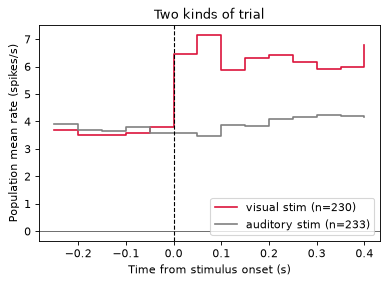

In [99]:
onset_column = 'stim_start_time'
population_rate = activity.mean(axis=1)

visual_onset_times = events.loc[events.is_vis_stim == 1, onset_column].values
auditory_onset_times = events.loc[events.is_aud_stim == 1, onset_column].values

plt.figure(figsize=(5.5, 3.5))
for onset_times_this_group, label, color in [(visual_onset_times, 'visual stim', 'crimson'),
                                  (auditory_onset_times, 'auditory stim', 'gray')]:
    aligned_windows_group, window_time_axis = align_to_event_times(population_rate, timestamps, onset_times_this_group, pre=0.3, post=0.5)
    mean_response = aligned_windows_group.mean(axis=0)
    plt.plot(window_time_axis, mean_response, color=color,
             label=f'{label} (n={len(aligned_windows_group)})')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('Time from stimulus onset (s)')
plt.ylabel('Population mean rate (spikes/s)')
plt.legend()
plt.title('Two kinds of trial')
plt.show()

In [ ]:
# Which column labels the chosen_condition? Look at the candidates first.
for col in ['stim_name', 'is_vis_stim', 'is_aud_stim', 'is_target', 'rewarded_modality']:
    if col in events.columns:
        print(f'--- {col} ---')
        print(events[col].value_counts().head(10).to_string())
        print()
condition_column = 'stim_name'
onset_column = 'stim_start_time'
stimulus_onset_times = visual_onset_times
is_selected_trial_type = events.is_vis_stim == 1

chosen_condition = events.loc[is_selected_trial_type, condition_column].value_counts().index[0]
onset_times = events.loc[is_selected_trial_type & (events[condition_column] == chosen_condition),
                    onset_column].values

print(f'condition: {chosen_condition} | presentations of this type: {len(onset_times)}')

--- stim_name ---
stim_name
sound1    124
vis1      123
sound2    109
vis2      107
catch      60

--- is_vis_stim ---
is_vis_stim
False    293
True     230

--- is_aud_stim ---
is_aud_stim
False    290
True     233

--- is_target ---
is_target
False    276
True     247

--- rewarded_modality ---
rewarded_modality
vis    262
aud    261

condition: vis1 | presentations of this type: 123


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Which cell or unit to look at?</h3>

Whatever your dataset calls them &mdash; ROIs in an imaging plane, sorted units on a probe &mdash;
taking the first one in the table is an arbitrary choice you did not disclose. Ranking by how strongly
they respond is a *different* undisclosed choice unless you say so. Pick deliberately and write down
how you picked.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Which signal do you align?</b> Most datasets ship more than one representation of the
same activity, and the choice is yours &mdash; but it is a choice, and it changes what the figures
show.

<table>
<tr><td><b>&Delta;F/F</b> (imaging)</td><td>Continuous fluorescence. Carries the indicator's rise and
decay, so a brief response is smeared forward by hundreds of milliseconds, and slow drift shared
across the field of view inflates correlations between any two cells. Every timepoint has a
value.</td></tr>
<tr><td><b>Deconvolved events</b> (imaging)</td><td>An estimate of when the cell actually fired, with
the indicator kinetics removed. Temporally tighter, and mostly exact zeros &mdash; so single-trial
estimates are much noisier even though the trial average looks cleaner.</td></tr>
<tr><td><b>Spike times</b> (electrophysiology)</td><td>Discrete times, no continuous trace at all. You
choose a bin width to get a matrix, and that width is a real analysis decision: too fine and every
bin is empty, too coarse and you lose the timing you came for.</td></tr>
</table>

None of these is the correct one. A question about response <i>latency</i> or duration is badly served
by &Delta;F/F; a question needing a reliable per-trial number is badly served by a sparse signal. Pick
one, say why, and if you have time run the analysis twice and compare &mdash; that comparison is
usually more informative than either result alone.

<b>Set the choice in one place</b> so switching it is a one-line edit rather than a rewrite.

</div>

In [ ]:
aligned_signal = activity
signal_label = 'spikes/s'
print('aligning', signal_label, '|', aligned_signal.shape)

aligning spikes/s | (138902, 84)


In [ ]:
pre, post = 0.3, 0.5

after = np.array([activity[(timestamps >= t0) & (timestamps < t0+0.2)].mean(axis=0)
                  for t0 in stimulus_onset_times])
before = np.array([activity[(timestamps >= t0-0.2) & (timestamps < t0)].mean(axis=0)
                   for t0 in stimulus_onset_times])
difference = after - before
with np.errstate(invalid='ignore'):
    modulation = np.nanmean(difference, axis=0) / np.nanstd(difference, axis=0)
example_roi = int(np.nanargmax(modulation))
print(f'most modulated unit: {example_roi} (score {modulation[example_roi]:.3f})')
print(f'median across units: {np.nanmedian(modulation):.3f}')

most modulated unit: 23 (score 1.919)
median across units: 0.287


In [ ]:
aligned_windows, t = align_to_event_times(activity[:, example_roi], timestamps, onset_times, pre=pre, post=post)
print('windows shape (n_presentations, n_frames):', aligned_windows.shape)

windows shape (n_presentations, n_frames): (123, 14)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compare the number of windows you got back against the number of onsets you
asked for. Are they the same?

If not, read the helper again and work out where the missing trials went &mdash; then decide whether
losing them matters for your analysis.

This is worth doing every time you call something that returns one row per trial. A function that
quietly returns fewer rows than you gave it will not raise an error; it will just make your
n smaller than you think it is.

</div>

In [ ]:
print('onsets:           ', len(onset_times))
print('windows returned: ', aligned_windows.shape[0])
print('trials dropped:   ', len(onset_times) - aligned_windows.shape[0])

onsets:            123
windows returned:  123
trials dropped:    0


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Raster and PSTH</h3>

The raster shows every trial; the PSTH is their average. Plot them together so you can see what the
average discards.

</div>

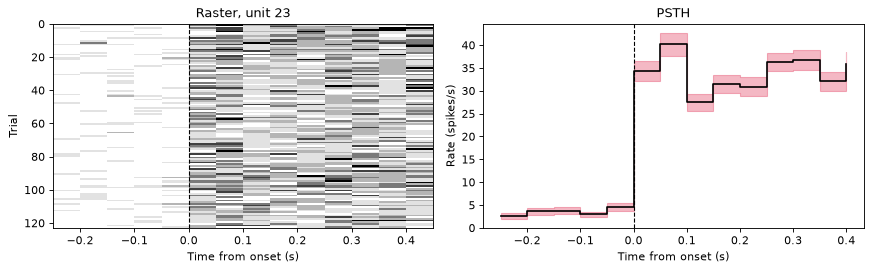

In [ ]:
mean = aligned_windows.mean(axis=0)
standard_error = aligned_windows.std(axis=0) / np.sqrt(len(aligned_windows))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sample_width = float(np.median(np.diff(t)))
axes[0].imshow(aligned_windows, aspect='auto', cmap='Greys', vmin=0,
               vmax=np.nanpercentile(aligned_windows, 99) or 1,
               interpolation='nearest',
               extent=[t[0], t[-1] + sample_width, len(aligned_windows), 0])
axes[0].set_ylabel('Trial')
axes[0].set_title(f'Raster, unit {example_roi}')
axes[1].plot(t, mean, 'k')
axes[1].fill_between(t, mean-standard_error, mean+standard_error, color='crimson',
                     alpha=0.3)
axes[1].set_ylabel('Rate (spikes/s)')
axes[1].set_title('PSTH')
for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
plt.tight_layout()
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now do it for every cell and plot the result as a heatmap, sorted by
response magnitude. How many cells respond at all?

</div>

In [ ]:
responses = []
for roi in range(activity.shape[1]):
    windows_roi, t = align_to_event_times(activity[:, roi], timestamps, onset_times, pre=pre, post=post)
    responses.append(windows_roi.mean(axis=0))
responses = np.array(responses)
print('responses shape (n_cells, n_timepoints):', responses.shape)

responses shape (n_cells, n_timepoints): (84, 14)


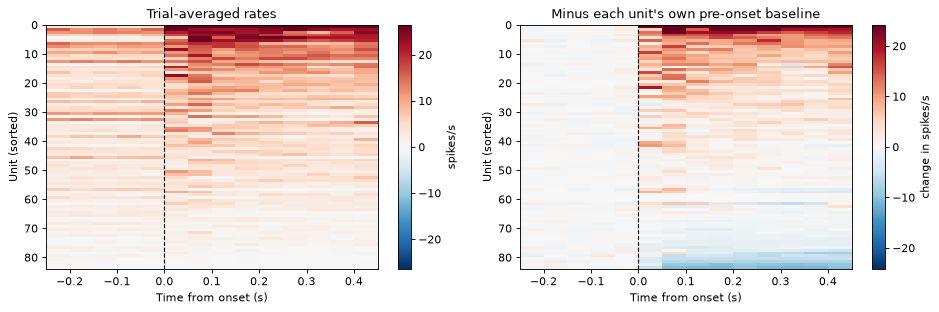

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order_raw = np.argsort(responses.mean(axis=1))[::-1]
lim = np.nanpercentile(np.abs(responses), 99)
sample_width = float(np.median(np.diff(t)))
im0 = axes[0].imshow(responses[order_raw], aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-lim, vmax=lim,
                     extent=[t[0], t[-1] + sample_width, len(responses), 0])
axes[0].set_title('Trial-averaged rates')
plt.colorbar(im0, ax=axes[0], label='spikes/s')

# Exclude the sample adjacent to onset: with binned data it can straddle
# the event, putting response into the baseline.
bin_width = np.median(np.diff(t))
baseline = responses[:, t < -bin_width].mean(axis=1, keepdims=True)
change = responses - baseline
order = np.argsort(change[:, t >= 0].mean(axis=1))[::-1]
lim = np.nanpercentile(np.abs(change), 99)
im1 = axes[1].imshow(change[order], aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-lim, vmax=lim,
                     extent=[t[0], t[-1] + sample_width, len(change), 0])
axes[1].set_title("Minus each unit's own pre-onset baseline")
plt.colorbar(im1, ax=axes[1], label='change in spikes/s')
for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
    ax.set_ylabel('Unit (sorted)')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The same analysis on a different signal</h3>

<b>Skip this section if your dataset has only one representation of activity.</b> A probe recording
gives you spike times and nothing else &mdash; there is no second signal to compare against, and
saying so in your write-up is the correct answer here, not a gap.

If you do have two &mdash; a continuous trace and a deconvolved estimate, most commonly &mdash; they
are not interchangeable, and running the same analysis on both is the cheapest way to find out how
much your conclusion depends on that choice.

<b>Check what your dataset has before assuming.</b> List the interfaces in the processing container
and see whether a second per-cell timeseries is there at all.

</div>

In [ ]:
if activity_events is not None:
    activity_events = np.where(np.abs(activity_events) < 1e-12, 0.0, activity_events)
    print('primary:', activity.shape, '| fraction exactly zero: %.3f' % (activity == 0).mean())
    print('second: ', activity_events.shape,
          '| fraction exactly zero: %.3f' % (activity_events == 0).mean())
    print('timestamps shared:', activity_events.shape[0] == len(timestamps))
else:
    print('this dataset has only one activity representation')

this dataset has only one activity representation


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** If your dataset has two activity representations, align both to the same
onsets and plot the trial-averaged population response side by side. What differs &mdash; the
duration, the shape, the size relative to baseline?

If it has only one, note that in your README and move on.

</div>

In [ ]:
comparison = [(signal_label, activity)]
if activity_events is not None:
    comparison.append(('second representation', activity_events))
if len(comparison) == 1:
    print('Only one activity representation in this dataset -- nothing to compare here.')
    print('Say so in your write-up and continue to Part 4.')

Only one activity representation in this dataset -- nothing to compare here.
Say so in your write-up and continue to Part 4.


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 4: Signal and noise correlations</h1>

<h3>First, the math</h3>

The Pearson correlation between two variables $x$ and $y$ is

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} $$

In words:

1. **Center** each variable by subtracting its mean.
2. **Multiply** the centered values pointwise and sum &mdash; large and positive when they vary
   together, negative when oppositely, near zero when unrelated.
3. **Normalize** by each variable's spread, forcing the result between -1 and +1.

Compute it once by hand before running it thousands of times.

</div>

In [ ]:
x = activity[:, 0]
y = activity[:, 1]
x_centered = x - x.mean()
y_centered = y - y.mean()
numerator = np.sum(x_centered * y_centered)
denominator = np.sqrt(np.sum(x_centered ** 2)) * np.sqrt(np.sum(y_centered ** 2))
print('n observations:  ', len(x))
print('r by hand:       ', round(numerator / denominator, 6))
print('r from np.corrcoef:', round(np.corrcoef(x, y)[0, 1], 6))

n observations:   138902
r by hand:        0.094268
r from np.corrcoef: 0.094268


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

Two consequences that matter for everything below:

- $r$ says nothing about response **size**, only whether two things move together.
- $r$ is computed over a set of paired observations, and **how many observations you have determines
  how noisy $r$ is** &mdash; but the value itself gives you no clue how many there were.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** What does a given value of $r$ look like? Simulate pairs with known
correlations and plot them.

</div>

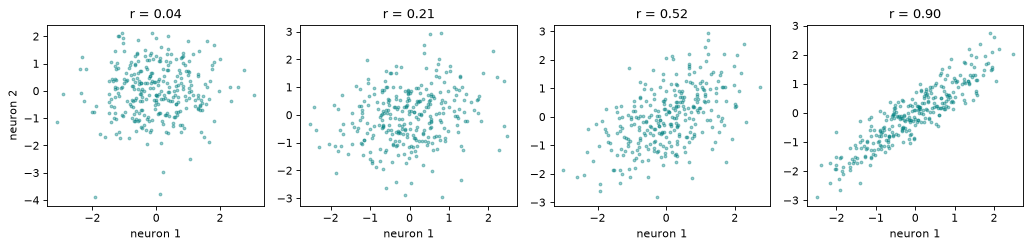

In [ ]:
rng = np.random.default_rng(0)
n = 300
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, target_r in zip(axes, [0.0, 0.2, 0.5, 0.9]):
    a = rng.normal(size=n)
    b = target_r * a + np.sqrt(1 - target_r ** 2) * rng.normal(size=n)
    ax.scatter(a, b, s=6, alpha=0.4, color='teal')
    ax.set_title(f'r = {np.corrcoef(a, b)[0, 1]:.2f}')
    ax.set_xlabel('neuron 1')
axes[0].set_ylabel('neuron 2')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Two reasons neurons are correlated</h3>

- **Signal correlation.** Do they respond similarly *across conditions*? Correlate the two neurons'
  tuning curves &mdash; their average response to each condition.
- **Noise correlation.** When the *same* condition repeats, do they fluctuate together around their
  own averages? Subtract each condition's mean and correlate the residuals.

A "condition" is whatever your event table repeats: an image, a grating direction, a tone, a
photostimulation target, a task context. All that matters is that it recurs enough times to average
over.

Same data, different thing averaged over:

| | what is correlated | one observation is |
| --- | --- | --- |
| signal | condition means | one condition |
| noise | within-condition residuals | one trial |

That last column matters more than anything else in this notebook.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 1: choose which events to use</h3>

Not every event is comparable to every other. Decide which subset is a fair comparison and write down
why.

</div>

In [ ]:
condition_column = 'stim_name'
onset_column = 'stim_start_time'

# What stimulus identities exist in the task table, and how many trials each?
print(events[condition_column].value_counts().to_string())
print()

# Keep every trial with a real stimulus. Restricting to visual trials alone
# would leave only 2 conditions; all four stimuli give 4. Catch trials have no
# stimulus, so they are dropped.
comparable_trials = events[events[condition_column].isin(['vis1', 'vis2', 'sound1', 'sound2'])].copy()

# What this does NOT control for: the rewarded modality changes between blocks,
# so two trials sharing a stimulus can differ in what the animal had to do.
all_onset_times = comparable_trials[onset_column].values
labels = comparable_trials[condition_column].values
print(f'{len(events)} events -> {len(comparable_trials)} after filtering')
print(f'{len(np.unique(labels))} conditions, '
      f'{int(pd.Series(labels).value_counts().median())} trials each (median)')

stim_name
sound1    124
vis1      123
sound2    109
vis2      107
catch      60

523 events -> 463 after filtering
4 conditions, 116 trials each (median)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 2: one number per trial per neuron</h3>

We need a `(n_trials, n_cells)` matrix. Average each aligned window over a response window, and
subtract a **baseline** from just before onset &mdash; otherwise each trial's "response" includes
wherever the cell happened to be sitting beforehand, and those levels drift together across the
population from bleaching, arousal, and movement.

<b>Choosing the two windows is dataset-specific.</b> The response window should cover the response
your Part 3 plot showed &mdash; look at it rather than copying a number from here, since a calcium
signal and a spike rate need very different windows. The baseline window should sit in the gap
before onset, and must **exclude any stimulation artifact**: with optogenetics or electrical
stimulation the frames around the pulse can be unusable, so leave a margin on both sides.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2a: choose the two windows.</b>

Every number in the correlation matrices below comes from these two windows, so this
is the most consequential cell in the section. Print how many samples each one holds:
if the answer is one or two, every response is an average of almost nothing and the
matrices will be dominated by sampling noise.

</div>

In [ ]:
response_window = (0.03, 0.20)      # spikes are fast; this is not a calcium window
baseline_window = (-0.20, -0.03)

# How many samples fall in each window? This is the sample size behind every
# single number in the response matrix.
sampling_interval = float(np.median(np.diff(timestamps)))
n_response_samples = int((response_window[1] - response_window[0]) / sampling_interval)
n_baseline_samples = int((baseline_window[1] - baseline_window[0]) / sampling_interval)

print(f'sampling interval : {sampling_interval*1000:.1f} ms')
print(f'response window   : {response_window} s -> ~{n_response_samples} samples')
print(f'baseline window   : {baseline_window} s -> ~{n_baseline_samples} samples')

sampling interval : 50.0 ms
response window   : (0.03, 0.2) s -> ~3 samples
baseline window   : (-0.2, -0.03) s -> ~3 samples


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2b: one trial, one cell.</b>

Before looping over thousands of trials, do the arithmetic once by hand and read the
numbers. If the subtraction is wrong here it is wrong everywhere, and a shape printed
at the end of a loop will not tell you.

</div>

In [ ]:
example_trial_time = all_onset_times[0]
example_cell = 0

# Boolean masks: which samples of the whole recording fall in each window for
# this one trial. >= start and < end so the windows never share a sample.
in_response = ((timestamps >= example_trial_time + response_window[0])
               & (timestamps < example_trial_time + response_window[1]))
in_baseline = ((timestamps >= example_trial_time + baseline_window[0])
               & (timestamps < example_trial_time + baseline_window[1]))

print(f'samples selected: {int(in_response.sum())} response, {int(in_baseline.sum())} baseline')
print(f'response values : {np.round(activity[in_response, example_cell], 3)}')
print(f'baseline values : {np.round(activity[in_baseline, example_cell], 3)}')

response_mean = np.nanmean(activity[in_response, example_cell])
baseline_mean = np.nanmean(activity[in_baseline, example_cell])
print(f'\nresponse mean {response_mean:.4f} - baseline mean {baseline_mean:.4f} '
      f'= {response_mean - baseline_mean:+.4f}')

samples selected: 4 response, 3 baseline
response values : [ 0.  0.  0. 20.]
baseline values : [0. 0. 0.]

response mean 5.0000 - baseline mean 0.0000 = +5.0000


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2c: one trial, every cell.</b>

The same two masks, applied to all cells at once. This gives one row of the matrix.
Check its length against the number of cells &mdash; a mismatch here means an axis is
transposed, which is easy to do and produces a plausible-looking matrix.

</div>

In [ ]:
one_trial_row = (np.nanmean(activity[in_response], axis=0)
                 - np.nanmean(activity[in_baseline], axis=0))

print('row shape:', one_trial_row.shape, '| n_cells:', activity.shape[1])
assert one_trial_row.shape[0] == activity.shape[1], 'row length must equal n_cells'
print('first 8 values:', np.round(one_trial_row[:8], 3))
print(f'cells responding above baseline on this trial: '
      f'{int((one_trial_row > 0).sum())} of {len(one_trial_row)}')

row shape: (84,) | n_cells: 84
first 8 values: [ 5.     5.    -6.667  0.    -6.667  0.     5.     0.   ]
cells responding above baseline on this trial: 40 of 84


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2d: every trial.</b>

Now the loop. A trial at the very start or end of the recording can have an empty
window, so those rows are filled with NaN rather than silently skipped &mdash; that way
the count is visible in the next step instead of vanishing.

</div>

In [ ]:
response_rows = []
for onset_time in all_onset_times:
    in_response = ((timestamps >= onset_time + response_window[0])
                   & (timestamps < onset_time + response_window[1]))
    in_baseline = ((timestamps >= onset_time + baseline_window[0])
                   & (timestamps < onset_time + baseline_window[1]))
    if in_response.sum() and in_baseline.sum():
        response_rows.append(np.nanmean(activity[in_response], axis=0)
                    - np.nanmean(activity[in_baseline], axis=0))
    else:
        response_rows.append(np.full(activity.shape[1], np.nan))

raw_response_matrix = np.array(response_rows)
print('raw matrix shape:', raw_response_matrix.shape, '(n_trials, n_cells)')
print('trials with any NaN:', int(np.isnan(raw_response_matrix).any(axis=1).sum()))
print('cells with any NaN :', int(np.isnan(raw_response_matrix).any(axis=0).sum()))

raw matrix shape: (463, 84) (n_trials, n_cells)
trials with any NaN: 0
cells with any NaN : 0


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Step 2e: drop incomplete trials, and keep the labels aligned.</b>

This is where silent bugs live. Dropping rows from the matrix without dropping the
same rows from the labels shifts every trial's condition by one &mdash; the analysis
still runs, the matrices still look plausible, and every result is wrong. Check the
two lengths against each other, every time.

</div>

In [ ]:
rows_kept = ~np.isnan(raw_response_matrix).any(axis=1)

trial_response_matrix = raw_response_matrix[rows_kept]
condition_labels = np.asarray(labels)[rows_kept]      # SAME mask, or labels desync

print(f'{len(raw_response_matrix)} trials -> {len(trial_response_matrix)} '
      f'({int((~rows_kept).sum())} dropped for incomplete windows)')
assert len(trial_response_matrix) == len(condition_labels), 'matrix and labels out of step'

print('\nR shape (n_trials, n_cells):', trial_response_matrix.shape)
print('conditions:', len(np.unique(condition_labels)))
print('trials per condition:',
      pd.Series(condition_labels).value_counts().to_dict())
print(f'\nfraction of single-trial responses exactly zero: {(trial_response_matrix == 0).mean():.3f}')
print('   (sparse signals give many empty single-trial estimates)')

463 trials -> 463 (0 dropped for incomplete windows)

R shape (n_trials, n_cells): (463, 84)
conditions: 4
trials per condition: {'sound1': 124, 'vis1': 123, 'sound2': 109, 'vis2': 107}

fraction of single-trial responses exactly zero: 0.441
   (sparse signals give many empty single-trial estimates)


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 3: tuning curves &mdash; look before correlating</h3>

</div>

In [ ]:
conditions = np.unique(condition_labels)
condition_mean_response = np.vstack([trial_response_matrix[condition_labels == c].mean(axis=0) for c in conditions])
print('tuning shape (n_conditions, n_cells):', condition_mean_response.shape)

tuning shape (n_conditions, n_cells): (4, 84)


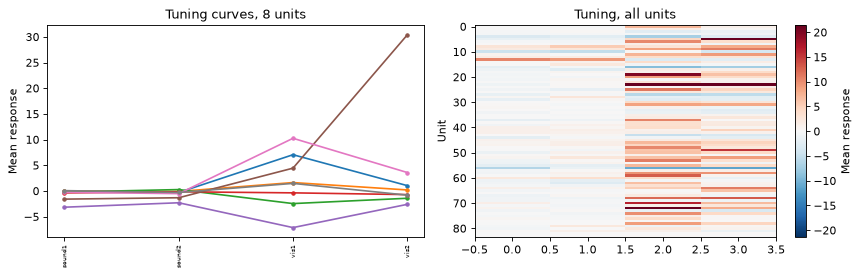

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for roi in range(min(8, condition_mean_response.shape[1])):
    axes[0].plot(range(len(conditions)), condition_mean_response[:, roi], marker='o', ms=3)
axes[0].set_xticks(range(len(conditions)))
axes[0].set_xticklabels([str(c) for c in conditions], rotation=90, fontsize=5)
axes[0].set_ylabel('Mean response')
axes[0].set_title('Tuning curves, 8 units')
lim = np.nanpercentile(np.abs(condition_mean_response), 99)
im = axes[1].imshow(condition_mean_response.T, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-lim, vmax=lim)
axes[1].set_ylabel('Unit')
axes[1].set_title('Tuning, all units')
plt.colorbar(im, ax=axes[1], label='Mean response')
plt.tight_layout()
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** How many numbers make up one neuron's tuning curve?

That is how many paired observations each signal correlation gets. Write it down.

</div>

In [ ]:
print('numbers per tuning curve:', condition_mean_response.shape[0])
print('trials available for noise correlations:', trial_response_matrix.shape[0])

numbers per tuning curve: 4
trials available for noise correlations: 463


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 4: residuals &mdash; look before correlating</h3>

Subtract **each condition's own mean**, not the grand mean. Subtracting the grand mean would leave
the differences between conditions in the residuals, making your "noise" correlation partly a signal
correlation.

</div>

In [ ]:
residuals = trial_response_matrix.copy().astype(float)
for c in conditions:
    m = condition_labels == c
    residuals[m] -= trial_response_matrix[m].mean(axis=0)
print('residuals shape:', residuals.shape)
print('mean of residuals (should be ~0):', round(float(residuals.mean()), 12))

residuals shape: (463, 84)
mean of residuals (should be ~0): 7.5778e-08


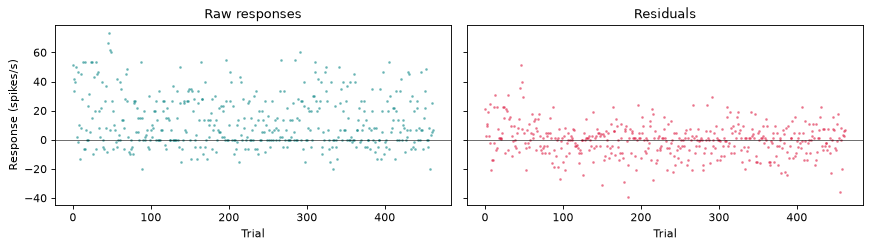

In [ ]:
roi = example_roi if example_roi < trial_response_matrix.shape[1] else 0
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
axes[0].plot(trial_response_matrix[:, roi], '.', ms=3, alpha=0.4, color='teal')
axes[0].set_title('Raw responses')
axes[1].plot(residuals[:, roi], '.', ms=3, alpha=0.4, color='crimson')
axes[1].set_title('Residuals')
for ax in axes:
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Trial')
axes[0].set_ylabel('Response (spikes/s)')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 5: correlate</h3>

`np.corrcoef` correlates **rows**, so transpose to get cells rather than trials. Getting this
backwards produces a plausible matrix of entirely the wrong thing &mdash; check the output shape
against the number of cells.

</div>

In [ ]:
signal_corr_matrix = np.corrcoef(condition_mean_response.T)
noise_corr_matrix = np.corrcoef(residuals.T)
pairs = np.triu_indices(trial_response_matrix.shape[1], k=1)
signal_values = signal_corr_matrix[pairs]
noise_values = noise_corr_matrix[pairs]
print(f'cells: {trial_response_matrix.shape[1]} -> unique pairs: {len(signal_values)}')
print(f'signal correlation: mean {np.nanmean(signal_values):+.4f}   ({condition_mean_response.shape[0]} observations per pair)')
print(f'noise  correlation: mean {np.nanmean(noise_values):+.4f}   ({trial_response_matrix.shape[0]} observations per pair)')

cells: 84 -> unique pairs: 3486
signal correlation: mean +0.2255   (4 observations per pair)
noise  correlation: mean +0.0127   (463 observations per pair)


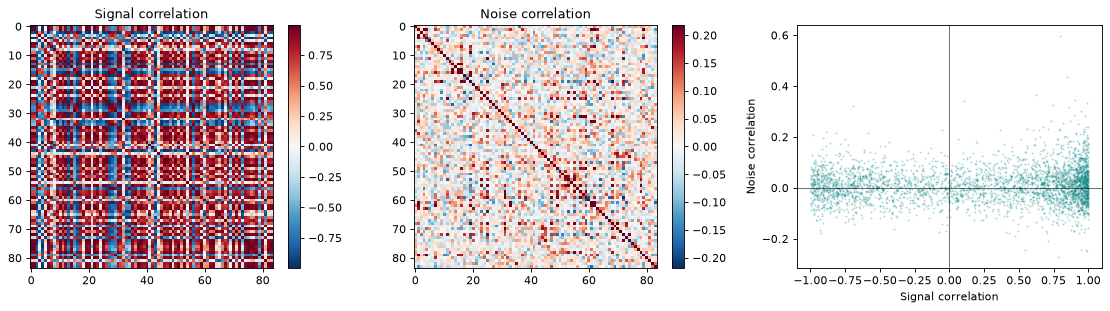

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, C, name in [(axes[0], signal_corr_matrix, 'Signal'), (axes[1], noise_corr_matrix, 'Noise')]:
    lim = np.nanpercentile(np.abs(C[pairs]), 99)
    im = ax.imshow(C, interpolation='nearest', cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(f'{name} correlation')
    plt.colorbar(im, ax=ax)
axes[2].plot(signal_values, noise_values, '.', ms=2, alpha=0.2, color='teal')
axes[2].set_xlabel('Signal correlation')
axes[2].set_ylabel('Noise correlation')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Is this result trustworthy?</h1>

Every number so far is a point estimate with no error bar. The single most useful check: **would you
get the same answer with half the data?**

Split trials in half at random, compute the correlations on each half separately, and correlate the
two halves' answers. Split **within each condition** so both halves see every condition.

Three outcomes, and all three are informative:

- **One high, one low** &mdash; trust the high one, and say why the other is not trustworthy.
- **Both high** &mdash; you have enough data for both; proceed.
- **Both near zero** &mdash; report that. It usually means the condition variable you chose does not
  organise these neurons' responses, however well-balanced it looked in the inventory. That is a
  real result about your dataset, and it is a better README than a matrix you cannot defend.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Before running it &mdash; which do you expect to be more reliable, signal or
noise correlations? Look back at the observation counts you wrote down.

</div>

In [ ]:
def signal_and_noise_correlations(responses, labels):
    """Signal and noise correlation matrices from a set of trials.

    responses : (n_trials, n_cells) one response value per trial per cell
    labels    : (n_trials,) which condition each trial belongs to

    Signal correlation = do two cells prefer the same conditions?
    Noise correlation  = do two cells co-vary trial to trial WITHIN a
                         condition, once the condition mean is removed?
    """
    conditions = np.unique(labels)

    # TUNING: one row per condition, holding that condition's mean response for
    # every cell. Averaging over trials is what removes trial-to-trial noise
    # and leaves the stimulus preference -- the "signal".
    condition_means = np.vstack([responses[labels == c].mean(axis=0)
                                 for c in conditions])

    # RESIDUALS: each trial minus its own condition's mean. What remains is
    # everything the condition does NOT explain -- the "noise". Subtracting the
    # condition mean is essential: skip it and the condition structure leaks
    # into the noise matrix and inflates it.
    residuals = responses.astype(float).copy()
    for c in conditions:
        in_condition = labels == c
        residuals[in_condition] -= responses[in_condition].mean(axis=0)

    # .T because np.corrcoef correlates ROWS: we want cell-by-cell matrices,
    # and cells are the columns of both arrays.
    #
    # Note the very different sample sizes feeding these two matrices: signal
    # is estimated from len(conditions) numbers per cell, noise from
    # len(labels) trials. That asymmetry is why they differ so much in
    # reliability even though both render as equally convincing heatmaps.
    return np.corrcoef(condition_means.T), np.corrcoef(residuals.T)


In [ ]:
def split_half_reliability(responses, labels, n_iter=10, seed=0):
    """How reproducible are the correlation matrices from independent trials?

    Splits the trials into two halves, computes the correlation matrices from
    each half separately, and asks how well the two agree. A high value means
    the structure is real; near zero means you are looking at noise.

    Returns (signal_reliability, noise_reliability) as Spearman correlations
    averaged over n_iter random splits.
    """
    rng = np.random.default_rng(seed)

    # Indices of the upper triangle, excluding the diagonal: the unique cell
    # pairs. Including the diagonal (always 1.0) would inflate the agreement.
    upper_triangle = np.triu_indices(responses.shape[1], k=1)

    signal_scores, noise_scores = [], []
    for _ in range(n_iter):
        half_a, half_b = [], []
        # Split WITHIN each condition, not across all trials at once, so both
        # halves see every condition. A blind split could leave a condition
        # entirely in one half, making its tuning undefined in the other.
        for c in np.unique(labels):
            idx = rng.permutation(np.flatnonzero(labels == c))
            n_half = len(idx) // 2
            if n_half < 1:
                continue                      # too few trials to split
            half_a.append(idx[:n_half])
            half_b.append(idx[n_half:2 * n_half])
        a, b = np.concatenate(half_a), np.concatenate(half_b)

        # Same computation on two disjoint trial sets.
        corr_a = signal_and_noise_correlations(responses[a], labels[a])
        corr_b = signal_and_noise_correlations(responses[b], labels[b])

        # Spearman rather than Pearson: we care whether the same PAIRS come out
        # ranked as most/least correlated, not whether values match exactly.
        signal_scores.append(stats.spearmanr(corr_a[0][upper_triangle],
                                             corr_b[0][upper_triangle],
                                             nan_policy='omit').statistic)
        noise_scores.append(stats.spearmanr(corr_a[1][upper_triangle],
                                            corr_b[1][upper_triangle],
                                            nan_policy='omit').statistic)
    return float(np.mean(signal_scores)), float(np.mean(noise_scores))

signal_reliability, noise_reliability = split_half_reliability(trial_response_matrix, condition_labels)
print('split-half reliability (agreement between two independent halves)')
print(f'  signal: {signal_reliability:.3f}')
print(f'  noise:  {noise_reliability:.3f}')

split-half reliability (agreement between two independent halves)
  signal: 0.746
  noise:  0.208


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Does the signal you chose change the answer?</h3>

Everything so far used one representation of activity. If your dataset provides a second one, repeat
the whole chain on it and compare the numbers that matter. If it provides only one, note that and
move on.

To repeat the chain you need the response-matrix construction as a reusable function rather than a
one-off block &mdash; so wrap it, the same way you wrapped the correlations.

</div>

In [ ]:
def trial_by_cell_responses(A):
    """Build the (n_trials, n_cells) baseline-subtracted response matrix.

    One number per trial per cell: mean activity in the response window minus
    mean activity in the baseline window. Every correlation below is computed
    from this matrix, so both window choices propagate into every later result.
    """
    response_rows = []
    for t0 in all_onset_times:
        # Boolean masks selecting the samples in each window for this trial.
        # >= start and < end so the two windows never share a sample.
        in_response = (timestamps >= t0 + response_window[0]) & (timestamps < t0 + response_window[1])
        in_baseline = (timestamps >= t0 + baseline_window[0]) & (timestamps < t0 + baseline_window[1])

        # nanmean, not mean: a single all-NaN cell would otherwise propagate
        # NaN across the whole row and silently cost you every trial.
        # A trial at the very start of the recording can have an empty
        # baseline window -- fill it with NaN and drop it below.
        response_rows.append(np.nanmean(A[in_response], axis=0) - np.nanmean(A[in_baseline], axis=0)
                    if in_response.sum() and in_baseline.sum()
                    else np.full(A.shape[1], np.nan))

    responses = np.array(response_rows)

    # Drop trials with any missing cell. Report the count if it is not zero:
    # trials vanishing here is exactly the kind of silent loss to check for.
    return responses[~np.isnan(responses).any(axis=1)]


In [ ]:
# Only one representation here, so vary the CONDITION DEFINITION instead.
# Rewarded modality (2 groups) vs stimulus identity (4) is the comparison:
# fewer, broader conditions vs more, narrower ones on the same trials.
response_rows = []
for name, lab in [('rewarded modality', comparable_trials.rewarded_modality.values[rows_kept]),
                  ('stimulus identity', condition_labels)]:
    signal_corr, noise_corr = signal_and_noise_correlations(trial_response_matrix, lab)
    upper_triangle = np.triu_indices(trial_response_matrix.shape[1], k=1)
    rs, rn = split_half_reliability(trial_response_matrix, lab)
    response_rows.append({'condition_definition': name,
                 'n_conditions': int(len(np.unique(lab))),
                 'reps_each': int(pd.Series(lab).value_counts().median()),
                 'signal_mean': round(float(np.nanmean(signal_corr[upper_triangle])), 4),
                 'noise_mean': round(float(np.nanmean(noise_corr[upper_triangle])), 4),
                 'signal_reliability': round(rs, 3),
                 'noise_reliability': round(rn, 3)})
pd.DataFrame(response_rows)

  condition_definition  n_conditions  reps_each  signal_mean  noise_mean  signal_reliability  noise_reliability
0    rewarded modality             2        231       0.0023      0.0392               0.123              0.567
1    stimulus identity             4        116       0.2255      0.0127               0.746              0.208

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>One column may not be the whole condition.</b>

A column can look like a clean condition variable &mdash; many levels, perfectly balanced &mdash;
while the stimulus varied in some <i>other</i> way at the same time. Two trials sharing that column's
value are then not repeats of the same thing, and averaging them together destroys the tuning you
were trying to measure.

Receptive-field mapping is the classic case: orientation is balanced, but the stimulus also moves
around the screen, so "144 repeats of 45&deg;" is really a handful of repeats at each of many
positions. The same trap appears whenever a design crosses two factors and you only notice one.

Check for it by asking what else varies across the trials you just called identical. Group by your
condition column, look at the other columns within a group, and see whether they are constant. If
they are not, either restrict to one level of the other factor, or make the condition the
<i>combination</i> of both.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Signal correlations need a condition that repeats. Does your dataset have
one?

Inventory the candidate columns: how many distinct values, how many repeats, how balanced.

Then answer **two separate questions**, because they can disagree:

1. **Is the analysis possible?** Does some column have enough conditions with enough repeats?
2. **Is it meaningful?** Does that column label something you would expect neurons to be tuned
   *to*, in a way that a correlation across condition means would capture?

A column can pass the first test and fail the second. State a verdict on both, and check it against
your reliability numbers.

</div>

In [ ]:
response_rows = []
for column in events.columns:
    values = events[column].dropna()
    if len(values) == 0:
        continue
    try:
        n_conditions = values.nunique()
    except TypeError:
        continue
    if not (2 <= n_conditions <= 200):
        continue
    counts = values.value_counts()
    response_rows.append({'column': column, 'n_conditions': int(n_conditions),
                 'min_reps': int(counts.min()), 'max_reps': int(counts.max()),
                 'balance': round(counts.min() / counts.max(), 2)})
pd.DataFrame(response_rows).sort_values('n_conditions', ascending=False)

                     column  n_conditions  min_reps  max_reps  balance
0               reward_time           141         1         1     1.00
5      trial_index_in_block            90         2         6     0.33
3               block_index             6        82        90     0.91
1                 stim_name             5        60       124     0.48
25            is_vis_target             2       123       400     0.31
20              is_aud_stim             2       233       290     0.80
21              is_vis_stim             2       230       293     0.78
22                 is_catch             2        60       463     0.13
23                is_target             2       247       276     0.89
24            is_aud_target             2       124       399     0.31
26             is_nontarget             2       216       307     0.70
18      is_reward_scheduled             2        30       493     0.06
27         is_aud_nontarget             2       109       414     0.26
28    

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Summary</h1>

<h3>The process</h3>

1. **Find out what is in the file** before analyzing it &mdash; and check that the dataset supports
   your question. Sometimes the answer is no.
2. **Plot the data after each transformation.** Single trials before averages; tuning curves before
   correlations.
3. **Name every decision.** Event subset, condition column, response window, baseline. Each is a
   fork, and each belongs in your methods.
4. **Try to break your own result.** Split the data in half and see if the answer survives.
5. **Let the dataset answer back.** If the check says your result is noise, or the dataset has no
   variable that supports your question, that is the finding. Report it rather than reaching for the
   analysis you planned to run.

<h3>Traps this notebook demonstrated</h3>

| trap | how you catch it |
| --- | --- |
| A result from few observations looks like one from many | split-half reliability |
| A well-balanced condition variable that means nothing | reliability, not the inventory |
| A condition column that hides a second varying factor | group by it, check what else moves |
| Analyzing units that should have been dropped | select on quality columns, and say so |
| A helper function silently drops data | compare output shape to input |
| A column exists but carries no information | check that it actually varies |
| One bad trial turns every cell's score into NaN | count your NaNs; use `nanmean` |
| Epoch comparisons confounded with time and behavior | check durations, order, behavior |
| An example cell chosen to look good | state your selection rule |
| Data looks absent but is stored elsewhere | look in every container first |
| An index from an earlier cell after reshaping the data | re-derive indices, never carry them |

<h3>Why this matters</h3>

You can generate an analysis faster than you can validate one. The only defense is to know your data
well enough that a wrong answer looks wrong to **you** &mdash; because it will not look wrong to the
code, and it will not look wrong on the plot.

</div>